### Copenhagen

In [1]:
import pandas as pd

path = '../../../raw-data/social-media/politicians_info_scraped.csv'

instagram_cph = pd.read_csv(path, sep=';')

print(instagram_cph.columns)

instagram_cph.head()

Index(['Bogstavbetegnelse', 'Listenavn', 'Navn', 'Rank', 'Instagram Tag',
       'Follower Count', 'Number of Posts'],
      dtype='object')


,Bogstavbetegnelse,Listenavn,Navn,Rank,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,Pernille Rosenkrantz-Theil,1,pernillerosenkrantztheil,12400.0,1154.0
1,A,Socialdemokratiet,Andreas Keil,2,brandmandkeil,832.0,32.0
2,A,Socialdemokratiet,Laura Rosenvinge,3,laurarosenvinge,1660.0,459.0
3,A,Socialdemokratiet,Jakob Hougaard,4,jakekbh,679.0,73.0
4,A,Socialdemokratiet,Maria Kornbek,5,mariakornbek,131.0,107.0


In [2]:
path = '../../../raw-data/election-2025/Kommunalvalg_2025_København_25-11-2025 14.54.11.csv'

votes_cph = pd.read_csv(path, sep=';')

print(votes_cph.columns)

votes_cph.head()

Index(['Afstemningsområde', 'Bogstavbetegnelse', 'Listenavn', 'Navn',
       'Stemmetal'],
      dtype='object')


,Afstemningsområde,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
0,1. 1. Østerbro,A,Socialdemokratiet,Listestemmer,336
1,1. 1. Østerbro,A,Socialdemokratiet,Pernille Rosenkrantz-Theil,339
2,1. 1. Østerbro,A,Socialdemokratiet,Andreas Keil,38
3,1. 1. Østerbro,A,Socialdemokratiet,Laura Rosenvinge,18
4,1. 1. Østerbro,A,Socialdemokratiet,Jakob Hougaard,10


In [3]:
# Exclude all total party votes
votes_cph = votes_cph[votes_cph['Navn'] != 'Listestemmer']

votes_cph.head()

,Afstemningsområde,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
1,1. 1. Østerbro,A,Socialdemokratiet,Pernille Rosenkrantz-Theil,339
2,1. 1. Østerbro,A,Socialdemokratiet,Andreas Keil,38
3,1. 1. Østerbro,A,Socialdemokratiet,Laura Rosenvinge,18
4,1. 1. Østerbro,A,Socialdemokratiet,Jakob Hougaard,10
5,1. 1. Østerbro,A,Socialdemokratiet,Maria Kornbek,14


In [4]:
# Sum votes from different polling areas for individual candidates
votes_cph = votes_cph.groupby(
    ['Bogstavbetegnelse', 'Listenavn', 'Navn'],
    as_index=False
)['Stemmetal'].sum()

votes_cph.head()

,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
0,A,Socialdemokratiet,Andreas Keil,960
1,A,Socialdemokratiet,Asbjørn Reissmann,375
2,A,Socialdemokratiet,Christoffer Rosenkrands,130
3,A,Socialdemokratiet,Edith Chenga Chamwi,189
4,A,Socialdemokratiet,Emery Karatasi,87


In [5]:
# Merge on politician names columns
merged = votes_cph.merge(
    instagram_cph,
    on=['Navn', 'Listenavn'],
    how='left'
)

merged.head()

,Bogstavbetegnelse_x,Listenavn,Navn,Stemmetal,Bogstavbetegnelse_y,Rank,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,Andreas Keil,960,A,2,brandmandkeil,832.0,32.0
1,A,Socialdemokratiet,Asbjørn Reissmann,375,A,24,asbjornreissmann,431.0,27.0
2,A,Socialdemokratiet,Christoffer Rosenkrands,130,A,21,rosenkrandschristoffer,133.0,2.0
3,A,Socialdemokratiet,Edith Chenga Chamwi,189,A,19,edithchamwi,142.0,0.0
4,A,Socialdemokratiet,Emery Karatasi,87,A,23,emmerk84,491.0,61.0


In [6]:
# Add columns indicating whether data about followers or posts is missing
merged['missing_followers'] = merged['Follower Count'].isna()
merged['missing_posts'] = merged['Number of Posts'].isna()

merged.head()

,Bogstavbetegnelse_x,Listenavn,Navn,Stemmetal,Bogstavbetegnelse_y,Rank,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts
0,A,Socialdemokratiet,Andreas Keil,960,A,2,brandmandkeil,832.0,32.0,False,False
1,A,Socialdemokratiet,Asbjørn Reissmann,375,A,24,asbjornreissmann,431.0,27.0,False,False
2,A,Socialdemokratiet,Christoffer Rosenkrands,130,A,21,rosenkrandschristoffer,133.0,2.0,False,False
3,A,Socialdemokratiet,Edith Chenga Chamwi,189,A,19,edithchamwi,142.0,0.0,False,False
4,A,Socialdemokratiet,Emery Karatasi,87,A,23,emmerk84,491.0,61.0,False,False


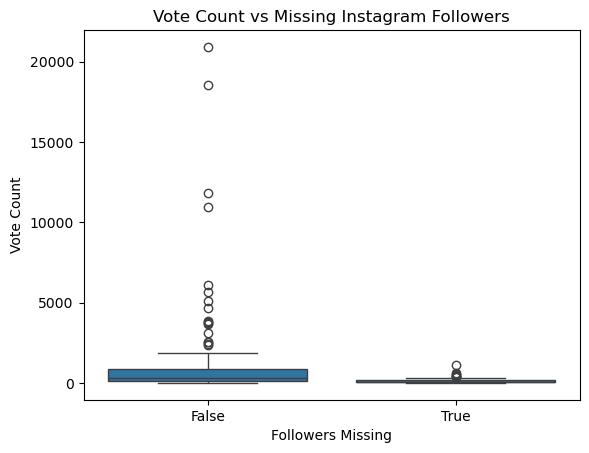

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged, x='missing_followers', y='Stemmetal')
plt.title('Vote Count vs Missing Instagram Followers')
plt.xlabel('Followers Missing')
plt.ylabel('Vote Count')
plt.show()

The linear-scale boxplot shows a clear difference in vote counts between politicians with and without Instagram follower data. Candidates with Instagram presence have a substantially higher median vote count and exhibit much greater variability, including all of the highest-vote outliers. In contrast, politicians without Instagram data receive consistently low vote counts, with very few candidates exceeding a few hundred votes. This suggests that having an Instagram presence is strongly associated with higher electoral potential, particularly for top-performing candidates. However, the presence of extreme outliers among Instagram-active politicians makes it difficult to assess typical candidate performance using the linear scale alone.

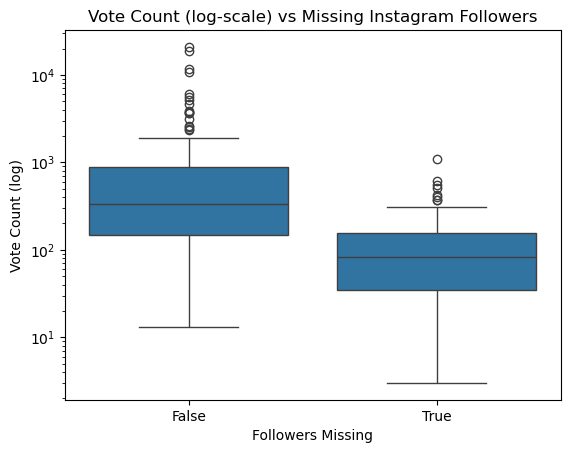

In [8]:
sns.boxplot(data=merged, x='missing_followers', y='Stemmetal')
plt.yscale('log')
plt.title('Vote Count (log-scale) vs Missing Instagram Followers')
plt.xlabel('Followers Missing')
plt.ylabel('Vote Count (log)')
plt.show()

The log-scale boxplot provides a clearer view of the typical vote distributions by reducing the influence of extreme outliers. Even after log transformation, politicians with Instagram data maintain a higher median vote count than those without, indicating that the association between Instagram presence and electoral support persists across multiple orders of magnitude. However, the distributions partially overlap, showing that many Instagram-active candidates still receive relatively few votes, while some candidates without Instagram presence achieve moderate success. This indicates that Instagram presence increases the potential for higher vote counts but is neither a necessary nor sufficient condition for individual electoral success.The log-scale boxplot for candidate-level votes reveals that, unlike the party-level results, missing Instagram data is not strongly associated with extremely low electoral support. Candidates without Instagram followers still receive substantial numbers of votes, indicating that personal social media presence is not a prerequisite for individual-level electoral success. However, the distribution shows that candidates with Instagram accounts tend to achieve higher median vote counts and display much greater variability, including several high-performing outliers. This suggests that while Instagram presence may enhance a candidate’s visibility and potential vote share, it is not a decisive factor in the same way it appears to be at the party level.

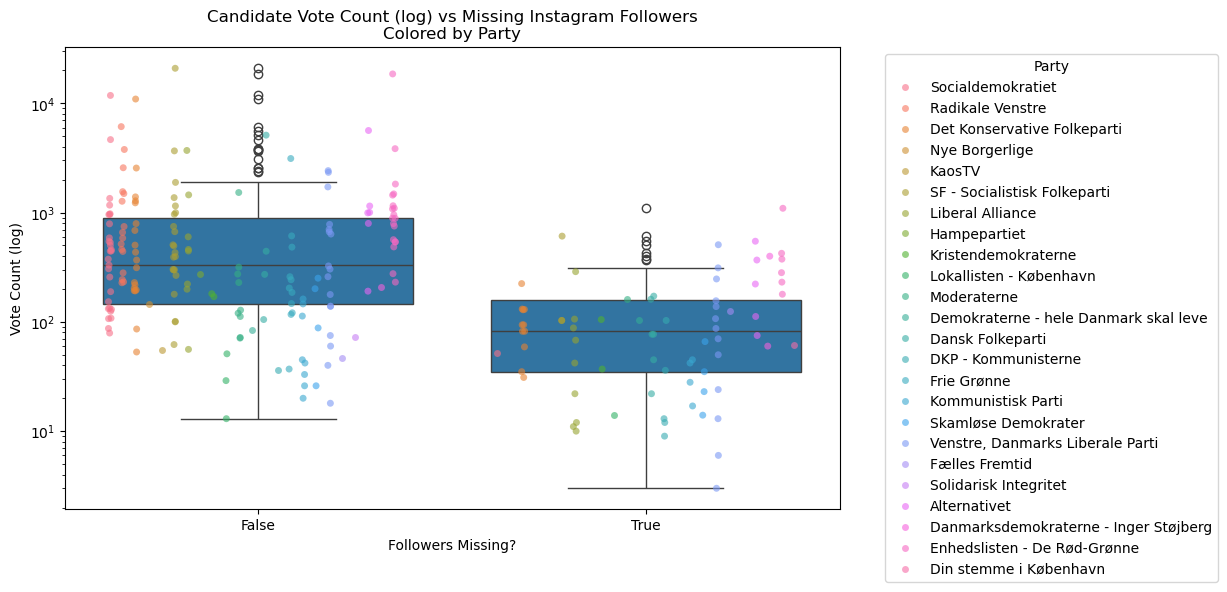

In [9]:
plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=merged,
    x='missing_followers',
    y='Stemmetal'
)

# Add individual data points colored by party
sns.stripplot(
    data=merged,
    x='missing_followers',
    y='Stemmetal',
    hue='Listenavn',       # party name
    dodge=True,
    jitter=True,
    alpha=0.6
)

plt.yscale('log')
plt.title('Candidate Vote Count (log) vs Missing Instagram Followers\nColored by Party')
plt.xlabel('Followers Missing?')
plt.ylabel('Vote Count (log)')
plt.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


When visualizing candidate vote counts on a log scale and distinguishing candidates by party affiliation, a consistent pattern emerges across the political spectrum. Candidates with Instagram presence exhibit higher median vote counts and account for nearly all high-vote outliers, regardless of party. In contrast, candidates without Instagram follower data are concentrated at low vote levels across all parties, suggesting that the observed association is not driven by a single dominant party. While party affiliation clearly influences overall electoral performance, Instagram presence appears to increase a candidate’s potential to achieve higher vote counts, though it is neither necessary nor sufficient for individual success.

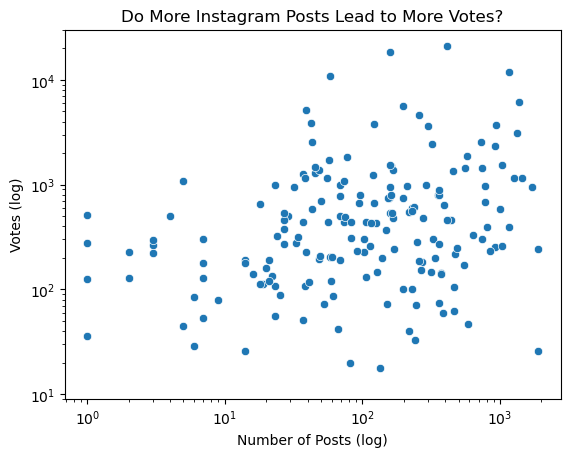

In [10]:
sns.scatterplot(
    data=merged,
    x='Number of Posts',
    y='Stemmetal'
)

plt.yscale('log')
plt.xscale('log')
plt.title('Do More Instagram Posts Lead to More Votes?')
plt.xlabel('Number of Posts (log)')
plt.ylabel('Votes (log)')
plt.show()


The scatter plot of Instagram posting frequency against vote counts shows no strong relationship, even after log transformation. Candidates with many posts do not systematically receive more votes than those with fewer posts, and high vote counts are observed across a wide range of posting activity. This indicates that posting frequency alone is a weak predictor of electoral success

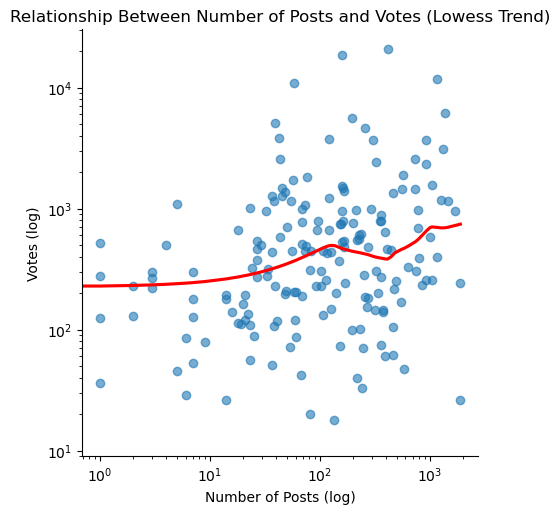

In [11]:
sns.lmplot(
    data=merged,
    x='Number of Posts',
    y='Stemmetal',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'},
    lowess=True
)

plt.xscale('log')
plt.yscale('log')
plt.title('Relationship Between Number of Posts and Votes (Lowess Trend)')
plt.xlabel('Number of Posts (log)')
plt.ylabel('Votes (log)')
plt.show()


The LOWESS-smoothed relationship between the number of Instagram posts and vote counts reveals a weak and non-linear association. While candidates who post more frequently tend to receive slightly higher vote counts on average, the effect is small compared to the influence of follower count. The large dispersion of votes at all posting levels indicates that posting frequency alone provides limited explanatory or predictive power. This suggests that activity without reach has only a marginal impact on electoral performance.

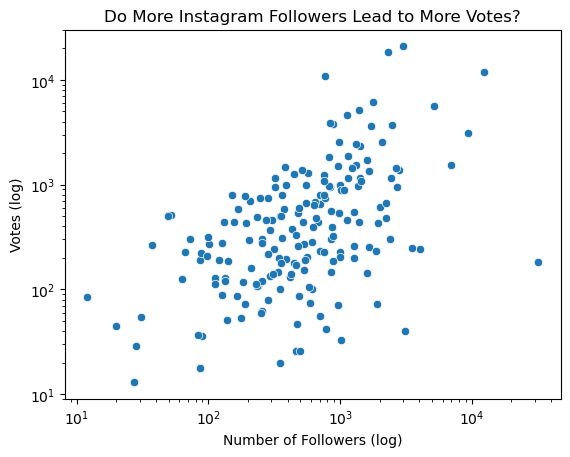

In [12]:
sns.scatterplot(
    data=merged,
    x='Follower Count',
    y='Stemmetal'
)

plt.yscale('log')
plt.xscale('log')
plt.title('Do More Instagram Followers Lead to More Votes?')
plt.xlabel('Number of Followers (log)')
plt.ylabel('Votes (log)')
plt.show()


The scatter plot of Instagram follower counts against vote totals on a log–log scale reveals a clear and robust positive association. Candidates with larger Instagram audiences consistently achieve higher vote counts, while candidates with few followers almost never receive substantial electoral support. Although considerable variation remains at each follower level, the overall pattern suggests that follower count is a much stronger indicator of electoral success than posting frequency, supporting the use of follower-based features in predictive models.

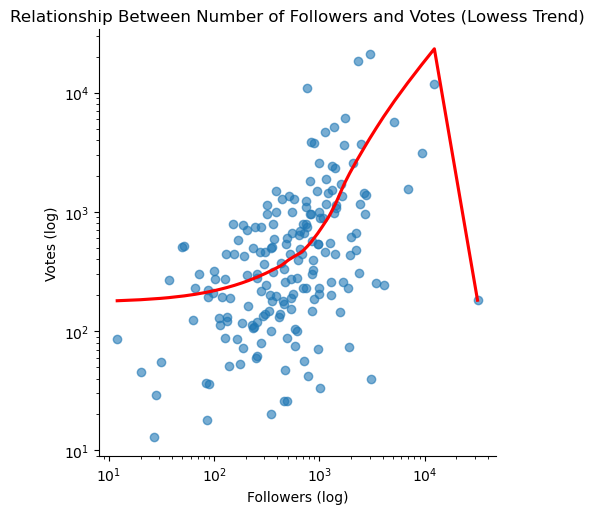

In [13]:
sns.lmplot(
    data=merged,
    x='Follower Count',
    y='Stemmetal',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'},
    lowess=True
)

plt.xscale('log')
plt.yscale('log')
plt.title('Relationship Between Number of Followers and Votes (Lowess Trend)')
plt.xlabel('Followers (log)')
plt.ylabel('Votes (log)')
plt.show()

The LOWESS-smoothed relationship between Instagram follower counts and vote totals reveals a strong, non-linear association across most of the observed range. Vote counts increase slowly at low follower levels and more rapidly as follower counts grow, indicating a multiplicative effect. A sharp downturn at the extreme high end of the follower distribution is likely driven by sparse observations and should be interpreted as a boundary artifact rather than a substantive reversal of the trend.

Instagram follower count is a robust indicator of electoral potential, particularly at higher levels of support, while posting frequency alone plays a minor role; consequently, non-linear models are required for candidate-level prediction, whereas simpler log-linear models suffice at the party level.

### Frederiksberg

In [14]:
path = '../../../raw-data/social-media/politicians_info_frb_scraped.csv'

instagram_frb = pd.read_csv(path, sep=';')

print(instagram_frb.columns)

instagram_frb.head()

Index(['Bogstavbetegnelse', 'Listenavn', 'Navn', 'Instagram Tag',
       'Follower Count', 'Number of Posts'],
      dtype='object')


,Bogstavbetegnelse,Listenavn,Navn,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,Michael Vindfeldt,mvindfeldt,5424.0,836.0
1,A,Socialdemokratiet,Sine Heltberg,sineheltberg,270.0,230.0
2,A,Socialdemokratiet,Malte Mathies Løcke,maltemathieslocke,856.0,181.0
3,A,Socialdemokratiet,Christina Sylvest-Noer,sylvest_noer,2027.0,623.0
4,A,Socialdemokratiet,Thomas Frank,stilladsarbejderen,190.0,41.0


In [15]:
path = '../../../raw-data/election-2025/Kommunalvalg_2025_Frederiksberg_25-11-2025 14.54.22.csv' 

votes_frb = pd.read_csv(path, sep=';')

print(votes_frb.columns)

votes_frb.head()

Index(['Afstemningsområde', 'Bogstavbetegnelse', 'Listenavn', 'Navn',
       'Stemmetal'],
      dtype='object')


,Afstemningsområde,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
0,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Listestemmer,310
1,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Michael Vindfeldt,709
2,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Sine Heltberg,68
3,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Malte Mathies Løcke,12
4,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Christina Sylvest-Noer,36


In [16]:
# Exclude all total party votes
votes_frb = votes_frb[votes_frb['Navn'] != 'Listestemmer']

votes_frb.head()

,Afstemningsområde,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
1,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Michael Vindfeldt,709
2,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Sine Heltberg,68
3,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Malte Mathies Løcke,12
4,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Christina Sylvest-Noer,36
5,"1. 10. Kreds, Søerne",A,Socialdemokratiet,Thomas Frank,8


In [17]:
# Sum votes from different polling areas for individual candidates
votes_frb = votes_frb.groupby(
    ['Bogstavbetegnelse', 'Listenavn', 'Navn'],
    as_index=False
)['Stemmetal'].sum()

votes_frb.head()

,Bogstavbetegnelse,Listenavn,Navn,Stemmetal
0,A,Socialdemokratiet,Asbjørn Dalgaard,10
1,A,Socialdemokratiet,Bjarne Henriksen,253
2,A,Socialdemokratiet,Britt Dam,172
3,A,Socialdemokratiet,Christina Sylvest-Noer,339
4,A,Socialdemokratiet,Christine Jørnø Vestergaard,167


In [18]:
# Merge on politician names columns
merged_frb = votes_frb.merge(
    instagram_frb,
    on=['Navn', 'Listenavn'],
    how='left'
)

merged_frb.head()

,Bogstavbetegnelse_x,Listenavn,Navn,Stemmetal,Bogstavbetegnelse_y,Instagram Tag,Follower Count,Number of Posts
0,A,Socialdemokratiet,Asbjørn Dalgaard,10,A,-,NaN,NaN
1,A,Socialdemokratiet,Bjarne Henriksen,253,A,bjarnehenriksen1801,5484.0,18.0
2,A,Socialdemokratiet,Britt Dam,172,A,brittzdam,745.0,80.0
3,A,Socialdemokratiet,Christina Sylvest-Noer,339,A,sylvest_noer,2027.0,623.0
4,A,Socialdemokratiet,Christine Jørnø Vestergaard,167,A,vestergaardchristine,178.0,515.0


In [19]:
# Add columns indicating whether data about followers or posts is missing
merged_frb['missing_followers'] = merged_frb['Follower Count'].isna()
merged_frb['missing_posts'] = merged_frb['Number of Posts'].isna()

merged_frb.head()

,Bogstavbetegnelse_x,Listenavn,Navn,Stemmetal,Bogstavbetegnelse_y,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts
0,A,Socialdemokratiet,Asbjørn Dalgaard,10,A,-,NaN,NaN,True,True
1,A,Socialdemokratiet,Bjarne Henriksen,253,A,bjarnehenriksen1801,5484.0,18.0,False,False
2,A,Socialdemokratiet,Britt Dam,172,A,brittzdam,745.0,80.0,False,False
3,A,Socialdemokratiet,Christina Sylvest-Noer,339,A,sylvest_noer,2027.0,623.0,False,False
4,A,Socialdemokratiet,Christine Jørnø Vestergaard,167,A,vestergaardchristine,178.0,515.0,False,False


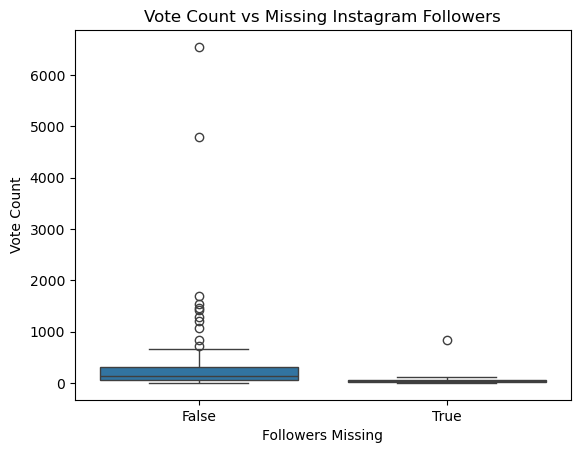

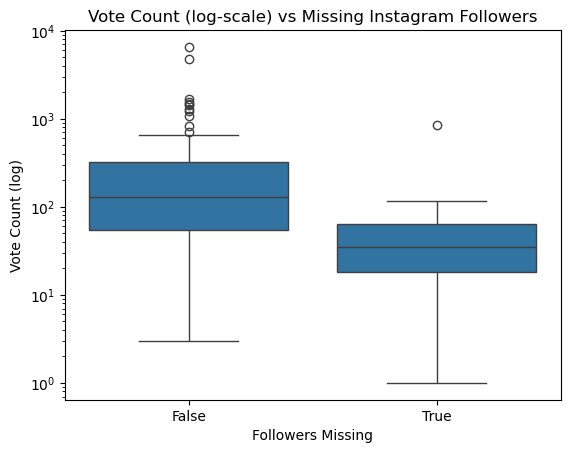

In [20]:
sns.boxplot(data=merged_frb, x='missing_followers', y='Stemmetal')
plt.title('Vote Count vs Missing Instagram Followers')
plt.xlabel('Followers Missing')
plt.ylabel('Vote Count')
plt.show()

sns.boxplot(data=merged_frb, x='missing_followers', y='Stemmetal')
plt.yscale('log')
plt.title('Vote Count (log-scale) vs Missing Instagram Followers')
plt.xlabel('Followers Missing')
plt.ylabel('Vote Count (log)')
plt.show()

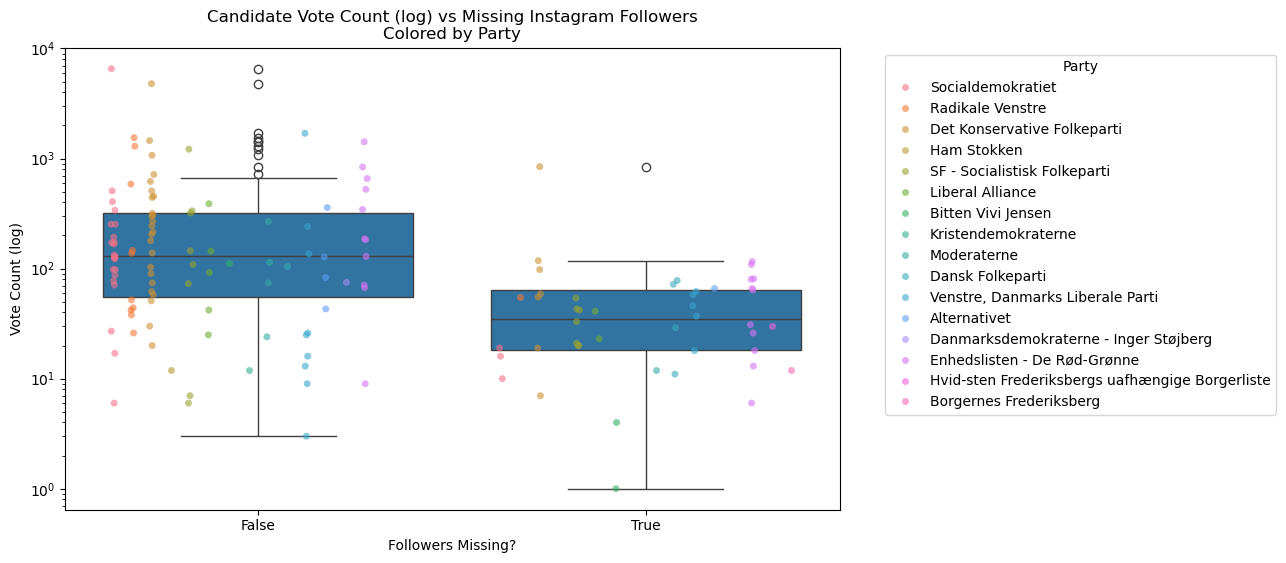

In [21]:
plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=merged_frb,
    x='missing_followers',
    y='Stemmetal'
)

# Add individual data points colored by party
sns.stripplot(
    data=merged_frb,
    x='missing_followers',
    y='Stemmetal',
    hue='Listenavn',       # party name
    dodge=True,
    jitter=True,
    alpha=0.6
)

plt.yscale('log')
plt.title('Candidate Vote Count (log) vs Missing Instagram Followers\nColored by Party')
plt.xlabel('Followers Missing?')
plt.ylabel('Vote Count (log)')
plt.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

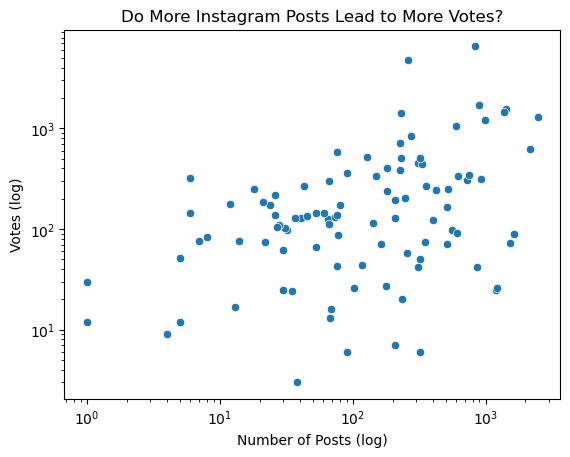

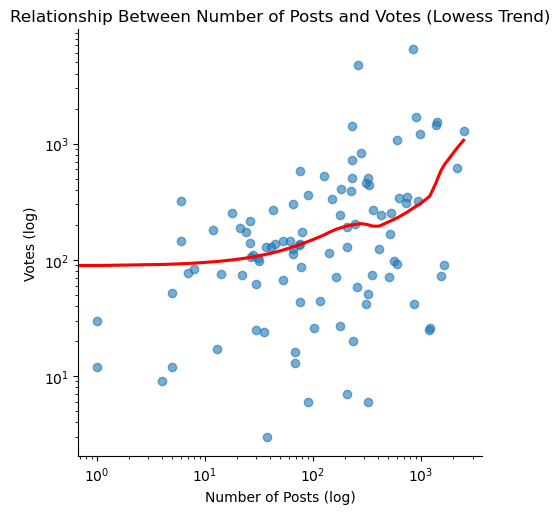

In [22]:
sns.scatterplot(
    data=merged_frb,
    x='Number of Posts',
    y='Stemmetal'
)

plt.yscale('log')
plt.xscale('log')
plt.title('Do More Instagram Posts Lead to More Votes?')
plt.xlabel('Number of Posts (log)')
plt.ylabel('Votes (log)')
plt.show()

sns.lmplot(
    data=merged_frb,
    x='Number of Posts',
    y='Stemmetal',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'},
    lowess=True
)

plt.xscale('log')
plt.yscale('log')
plt.title('Relationship Between Number of Posts and Votes (Lowess Trend)')
plt.xlabel('Number of Posts (log)')
plt.ylabel('Votes (log)')
plt.show()

For Frederiksberg candidates, Instagram posting frequency shows a slightly stronger association with vote counts than observed in Copenhagen. The LOWESS-smoothed trend suggests that candidates who post more frequently tend to receive higher vote counts on average, particularly at higher activity levels. However, the substantial variance across all posting levels indicates that posting frequency alone remains a weak predictor of electoral success, especially compared to follower count.

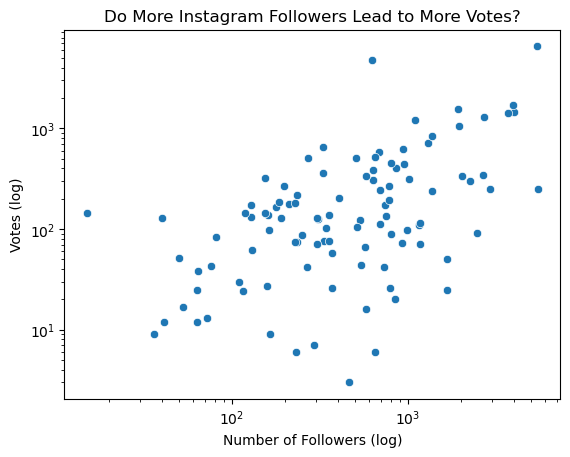

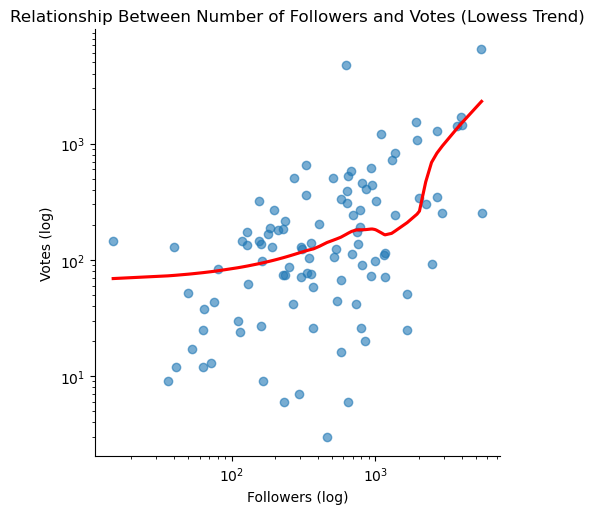

In [23]:
sns.scatterplot(
    data=merged_frb,
    x='Follower Count',
    y='Stemmetal'
)

plt.yscale('log')
plt.xscale('log')
plt.title('Do More Instagram Followers Lead to More Votes?')
plt.xlabel('Number of Followers (log)')
plt.ylabel('Votes (log)')
plt.show()

sns.lmplot(
    data=merged_frb,
    x='Follower Count',
    y='Stemmetal',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'},
    lowess=True
)

plt.xscale('log')
plt.yscale('log')
plt.title('Relationship Between Number of Followers and Votes (Lowess Trend)')
plt.xlabel('Followers (log)')
plt.ylabel('Votes (log)')
plt.show()

For Frederiksberg candidates, Instagram follower count exhibits a clear and robust positive association with vote totals. Both the scatter plot and the LOWESS-smoothed trend indicate that candidates with larger follower bases consistently receive higher vote counts, with the relationship strengthening at higher follower levels. This suggests that Instagram reach plays a significant role in shaping electoral outcomes even in smaller, local elections.

### Combined


Although some differences were observed between Copenhagen and Frederiksberg candidates particularly in the strength of the association between posting frequency and votes the direction and overall structure of the relationships were consistent across municipalities. Instagram follower count remained a strong predictor of vote totals in both contexts. Consequently, candidates from both municipalities were pooled into a single dataset for modeling, with municipality included as a control variable to account for contextual differences.

In [24]:
merged["municipality"] = "Copenhagen"
merged_frb["municipality"] = "Frederiksberg"

print(merged.columns)
print(merged_frb.columns)


Index(['Bogstavbetegnelse_x', 'Listenavn', 'Navn', 'Stemmetal',
       'Bogstavbetegnelse_y', 'Rank', 'Instagram Tag', 'Follower Count',
       'Number of Posts', 'missing_followers', 'missing_posts',
       'municipality'],
      dtype='object')
Index(['Bogstavbetegnelse_x', 'Listenavn', 'Navn', 'Stemmetal',
       'Bogstavbetegnelse_y', 'Instagram Tag', 'Follower Count',
       'Number of Posts', 'missing_followers', 'missing_posts',
       'municipality'],
      dtype='object')


In [25]:
candidates_all = pd.concat(
    [merged, merged_frb],
    axis=0,
    ignore_index=True
)

candidates_all.head()

,Bogstavbetegnelse_x,Listenavn,Navn,Stemmetal,Bogstavbetegnelse_y,Rank,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts,municipality
0,A,Socialdemokratiet,Andreas Keil,960,A,2.0,brandmandkeil,832.0,32.0,False,False,Copenhagen
1,A,Socialdemokratiet,Asbjørn Reissmann,375,A,24.0,asbjornreissmann,431.0,27.0,False,False,Copenhagen
2,A,Socialdemokratiet,Christoffer Rosenkrands,130,A,21.0,rosenkrandschristoffer,133.0,2.0,False,False,Copenhagen
3,A,Socialdemokratiet,Edith Chenga Chamwi,189,A,19.0,edithchamwi,142.0,0.0,False,False,Copenhagen
4,A,Socialdemokratiet,Emery Karatasi,87,A,23.0,emmerk84,491.0,61.0,False,False,Copenhagen


In [26]:
# Sanity check
len(merged), len(merged_frb), len(candidates_all)


(261, 149, 410)

In [27]:
# Sanity check 2
candidates_all["municipality"].value_counts()

municipality
Copenhagen       261
Frederiksberg    149
Name: count, dtype: int64

In [28]:
candidates_all.head()


,Bogstavbetegnelse_x,Listenavn,Navn,Stemmetal,Bogstavbetegnelse_y,Rank,Instagram Tag,Follower Count,Number of Posts,missing_followers,missing_posts,municipality
0,A,Socialdemokratiet,Andreas Keil,960,A,2.0,brandmandkeil,832.0,32.0,False,False,Copenhagen
1,A,Socialdemokratiet,Asbjørn Reissmann,375,A,24.0,asbjornreissmann,431.0,27.0,False,False,Copenhagen
2,A,Socialdemokratiet,Christoffer Rosenkrands,130,A,21.0,rosenkrandschristoffer,133.0,2.0,False,False,Copenhagen
3,A,Socialdemokratiet,Edith Chenga Chamwi,189,A,19.0,edithchamwi,142.0,0.0,False,False,Copenhagen
4,A,Socialdemokratiet,Emery Karatasi,87,A,23.0,emmerk84,491.0,61.0,False,False,Copenhagen


Candidate-level data from Copenhagen and Frederiksberg were combined into a single dataset to increase sample size and improve model robustness. A municipality indicator was included to control for contextual differences between the two locations.

In [29]:
path = "../../preprocessing/instagram/2025-votes-candidates-instagram.csv"
candidates_all.to_csv(path, index=False)